# 👥 07 - Project Summary for Presentation

# Sistema de análisis y predicción de desempeño de empleados

## Resumen ejecutivo final del proyecto

### Integrantes
- Arturo

---

# Objetivo del proyecto

Desarrollar un sistema de análisis y predicción de desempeño de empleados utilizando técnicas de Machine Learning aplicadas a datos de Recursos Humanos.

El objetivo principal fue identificar empleados de alto desempeño y detectar factores de riesgo organizacional antes de que generen problemas reales de rotación.

---

# Problema de negocio

La gestión de personas enfrenta múltiples factores de riesgo difíciles de anticipar:

- ausencias frecuentes no justificadas;
- baja participación en capacitaciones;
- brechas en competencias técnicas y blandas;
- empleados con perfil de riesgo de rotación;
- desempeño bajo en periodos consecutivos.

Estas situaciones pueden provocar:

- pérdida de talento clave;
- caída en productividad organizacional;
- aumento de costos de contratación y reemplazos;
- deterioro del clima laboral.


# 📦 1. Construcción del dataset

Para el proyecto se integraron cuatro fuentes de datos de RRHH:

- `empleados.csv` — datos de cargo, departamento, contrato y jornada
- `ausencias.csv` — registros históricos de inasistencias por tipo y días
- `capacitaciones.csv` — cursos, horas, estado y notas finales
- `evaluaciones.csv` — puntajes de desempeño y competencias por periodo

---

## Resultado final

Después del proceso de integración y transformación se construyó:

# `dataset_rrhh_limpio.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

project_root = r'C:\Users\Arturo\Desktop\Prueba1'

df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print(df.shape)
df.head(3)


(478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126


# 📊 2. Análisis exploratorio

Distribución del puntaje de desempeño — variable objetivo del proyecto.


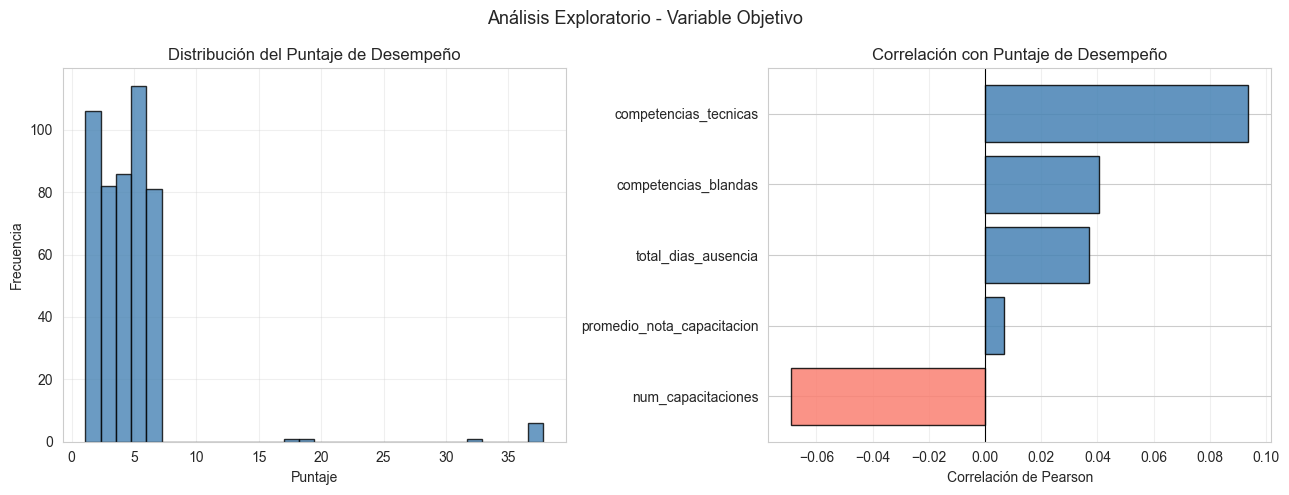

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['puntaje_desempeno'].dropna(), bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución del Puntaje de Desempeño')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

vars_corr = ['competencias_tecnicas', 'competencias_blandas',
             'promedio_nota_capacitacion', 'total_dias_ausencia', 'num_capacitaciones']
vars_corr = [v for v in vars_corr if v in df.columns]
corrs = df[vars_corr + ['puntaje_desempeno']].corr()['puntaje_desempeno'].drop('puntaje_desempeno').sort_values()

colores = ['salmon' if v < 0 else 'steelblue' for v in corrs.values]
axes[1].barh(corrs.index, corrs.values, color=colores, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con Puntaje de Desempeño')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Análisis Exploratorio - Variable Objetivo', fontsize=13)
plt.tight_layout()
plt.show()


# ⚙️ 3. Feature Engineering

Variables creadas más importantes:

- `competencia_combinada` — suma ponderada de competencias técnicas y blandas
- `eficiencia_capacitacion` — nota promedio por hora de capacitación
- `brecha_nota_capacitacion` — diferencia entre nota máxima y promedio
- `ausencia_alta` — flag de empleados en cuartil superior de ausencias
- `riesgo_operacional_rrhh` — indicador combinado de riesgo por persona
- `riesgo_rotacion` — alta ausencia + bajo desempeño simultáneamente


# 🎯 4. Targets del proyecto

| Target | Tipo | Definición |
|---|---|---|
| `desempeno_alto` | Clasificación binaria | Puntaje ≥ P75 |
| `puntaje_desempeno` | Regresión continua | Valor numérico directo |

**Variables excluidas por data leakage:** `desempeno_bajo`, `riesgo_rotacion`, `id_empleado`.


In [3]:
umbral = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = np.where(df['puntaje_desempeno'] >= umbral, 1, 0)

print(f"Umbral desempeno_alto (P75): {umbral:.2f}")
print(f"Clase 0 (normal):       {(df['desempeno_alto']==0).sum()} empleados")
print(f"Clase 1 (alto desempeño): {(df['desempeno_alto']==1).sum()} empleados")


Umbral desempeno_alto (P75): 5.60
Clase 0 (normal):       354 empleados
Clase 1 (alto desempeño): 124 empleados


# 📈 5. Modelos supervisados — Clasificación

Se probaron 6 clasificadores con `class_weight='balanced'` para compensar el desbalance de clases (~75/25).


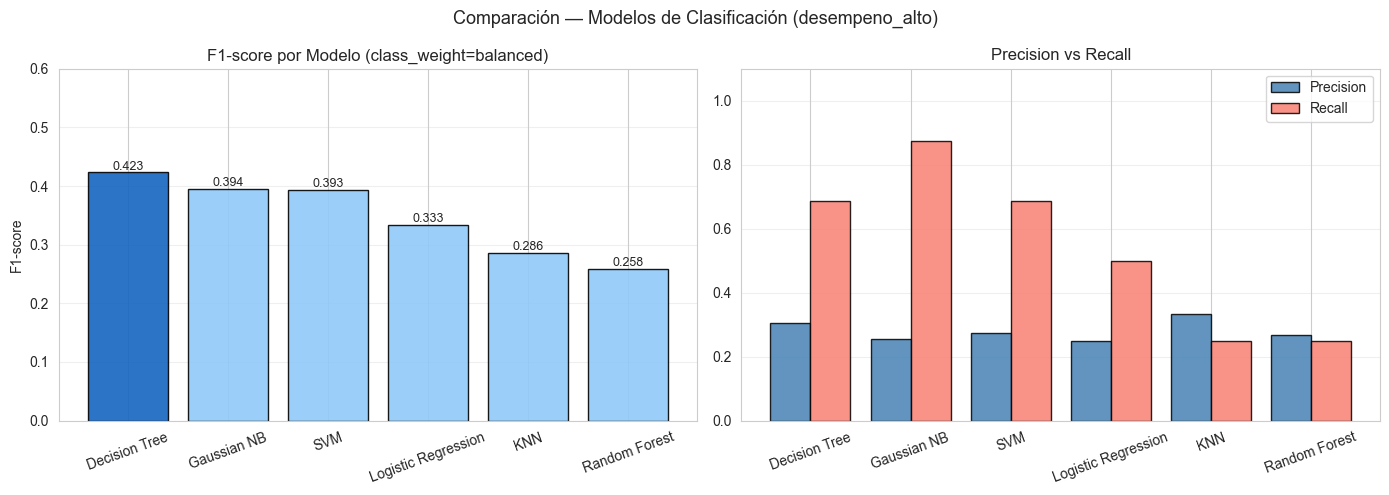

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.5161,0.5720,0.3056,0.6875,0.4231
1,Gaussian NB,0.3065,0.4918,0.2545,0.8750,0.3944
2,SVM,0.4516,0.5285,0.2750,0.6875,0.3929
3,Logistic Regression,0.4839,0.4891,0.2500,0.5000,0.3333
4,KNN,0.6774,0.5380,0.3333,0.2500,0.2857
5,Random Forest,0.6290,0.5054,0.2667,0.2500,0.2581


In [4]:
# Resultados reales — notebook 03.
resultados_clf = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Gaussian NB', 'SVM',
               'Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy':          [0.5161, 0.3065, 0.4516, 0.4839, 0.6774, 0.6290],
    'Balanced Accuracy': [0.5720, 0.4918, 0.5285, 0.4891, 0.5380, 0.5054],
    'Precision':         [0.3056, 0.2545, 0.2750, 0.2500, 0.3333, 0.2667],
    'Recall':            [0.6875, 0.8750, 0.6875, 0.5000, 0.2500, 0.2500],
    'F1-score':          [0.4231, 0.3944, 0.3929, 0.3333, 0.2857, 0.2581]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-score.
colores_f1 = ['#1565C0' if f == resultados_clf['F1-score'].max() else '#90CAF9'
              for f in resultados_clf['F1-score']]
bars = axes[0].bar(resultados_clf['Modelo'], resultados_clf['F1-score'],
                   color=colores_f1, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, resultados_clf['F1-score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[0].set_title('F1-score por Modelo (class_weight=balanced)')
axes[0].set_ylim(0, 0.6)
axes[0].set_ylabel('F1-score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# Recall vs Precision.
x = range(len(resultados_clf))
axes[1].bar([i - 0.2 for i in x], resultados_clf['Precision'], width=0.4,
            label='Precision', color='steelblue', alpha=0.85, edgecolor='black')
axes[1].bar([i + 0.2 for i in x], resultados_clf['Recall'], width=0.4,
            label='Recall', color='salmon', alpha=0.85, edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(resultados_clf['Modelo'], rotation=20)
axes[1].set_title('Precision vs Recall')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparación — Modelos de Clasificación (desempeno_alto)', fontsize=13)
plt.tight_layout()
plt.show()

resultados_clf.sort_values('F1-score', ascending=False)


# 📌 Mejor clasificador — Decision Tree

| Métrica | Valor |
|---|---|
| Accuracy | 0.5161 |
| Balanced Accuracy | 0.5720 |
| Precision | 0.3056 |
| Recall | **0.6875** |
| F1-score | **0.4231** |

El recall alto (0.69) es clave en contextos de RRHH: el modelo detecta la mayoría de los empleados de alto desempeño, minimizando falsos negativos (empleados talentosos no identificados).


# 📉 6. Modelos supervisados — Regresión

Se probaron 5 regresores y se aplicó validación cruzada (CV=5) para evaluar con mayor estabilidad.


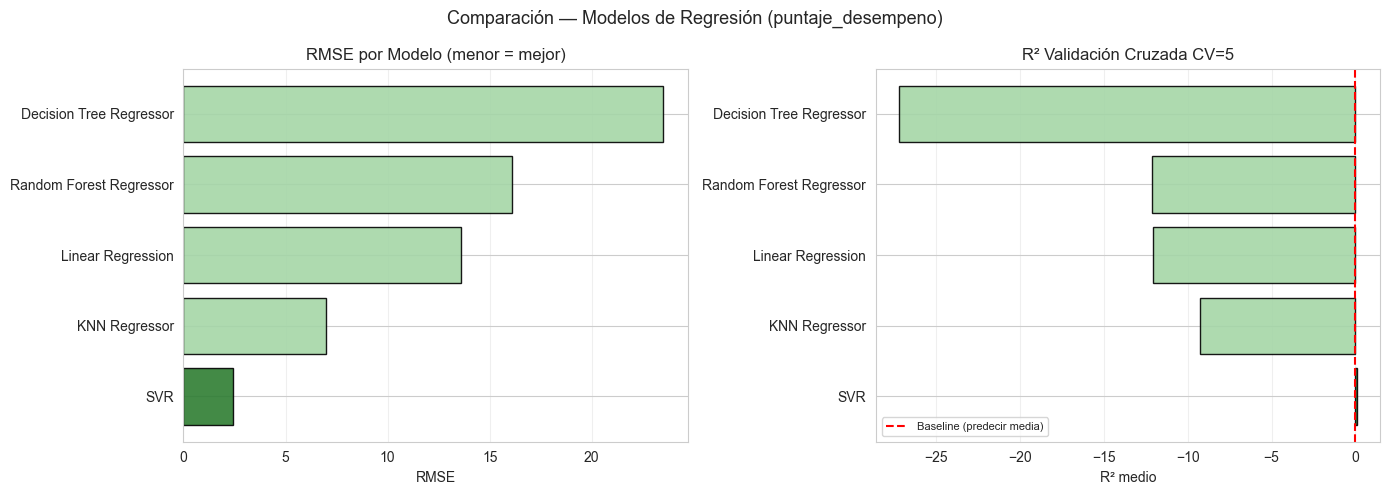

,Modelo,MAE,RMSE,R²,R² CV
0,SVR,1.3713,2.4264,0.2895,0.0977
1,KNN Regressor,2.7284,6.9946,-4.9039,-9.2330
2,Linear Regression,9.9738,13.5858,-21.2733,-12.0912
3,Random Forest Regressor,5.7134,16.1018,-30.2870,-12.1308
4,Decision Tree Regressor,4.9383,23.5184,-65.7471,-27.2050


In [5]:
# Resultados reales — notebook 03.
resultados_reg = pd.DataFrame({
    'Modelo': ['SVR', 'KNN Regressor', 'Linear Regression',
               'Random Forest Regressor', 'Decision Tree Regressor'],
    'MAE':    [1.3713,  2.7284,   9.9738,   5.7134,   4.9383],
    'RMSE':   [2.4264,  6.9946,  13.5858,  16.1018,  23.5184],
    'R²':     [0.2895, -4.9039, -21.2733, -30.2870, -65.7471],
    'R² CV':  [0.0977, -9.2330, -12.0912, -12.1308, -27.2050]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_rmse = ['#2E7D32' if m == resultados_reg['RMSE'].min() else '#A5D6A7'
                for m in resultados_reg['RMSE']]
axes[0].barh(resultados_reg['Modelo'], resultados_reg['RMSE'],
             color=colores_rmse, edgecolor='black', alpha=0.9)
axes[0].set_title('RMSE por Modelo (menor = mejor)')
axes[0].set_xlabel('RMSE')
axes[0].grid(alpha=0.3, axis='x')

colores_r2 = ['#2E7D32' if r == max(resultados_reg['R² CV']) else '#A5D6A7'
              for r in resultados_reg['R² CV']]
axes[1].barh(resultados_reg['Modelo'], resultados_reg['R² CV'],
             color=colores_r2, edgecolor='black', alpha=0.9)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5, label='Baseline (predecir media)')
axes[1].set_title('R² Validación Cruzada CV=5')
axes[1].set_xlabel('R² medio')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Comparación — Modelos de Regresión (puntaje_desempeno)', fontsize=13)
plt.tight_layout()
plt.show()

resultados_reg.sort_values('RMSE')


# 📌 Mejor regresor — SVR

| Métrica | Test | CV=5 |
|---|---|---|
| MAE | 1.3713 | — |
| RMSE | **2.4264** | — |
| R² | 0.2895 | **0.0977** |

SVR es el único modelo con R² positivo: explica aproximadamente el 10% de la varianza del puntaje en validación cruzada.

El R² bajo refleja una limitación estructural del dataset: con 309 empleados y features agregados por persona, la señal predictiva es débil pero no nula.


# 🔧 7. Optimización de hiperparámetros — Random Forest

Se aplicaron tres enfoques sobre Random Forest Classifier y Regressor para evaluar si la optimización mejora los resultados base.


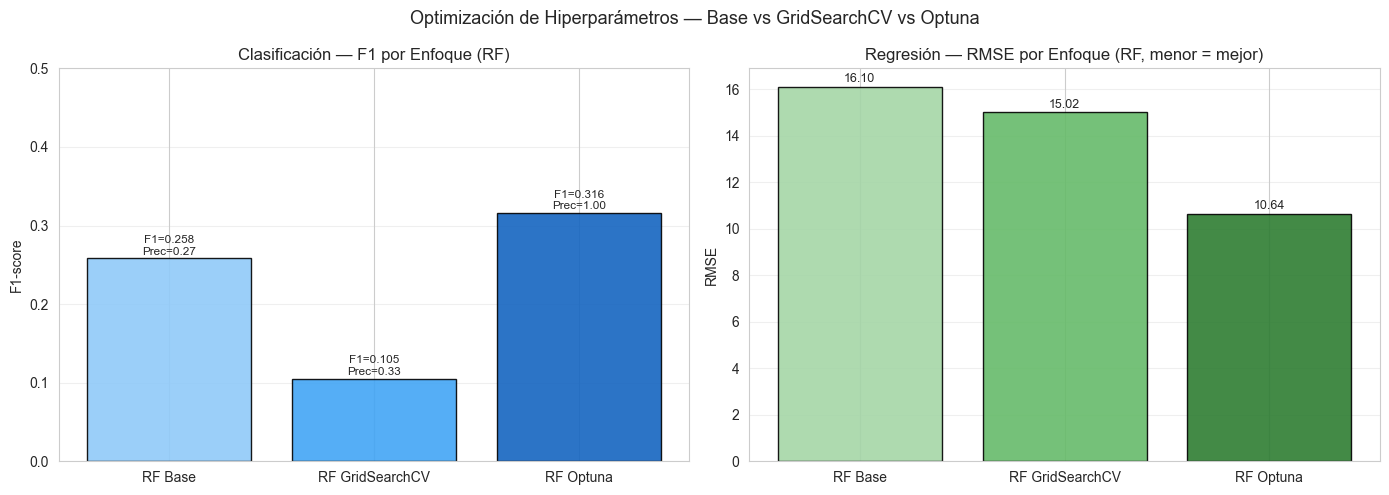

== Clasificación ==


,Enfoque,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,RF Base,0.629032,0.505435,0.266667,0.2500,0.258065
1,RF GridSearchCV,0.725806,0.509511,0.333333,0.0625,0.105263
2,RF Optuna,0.790323,0.593750,1.000000,0.1875,0.315789


== Regresión ==


,Enfoque,MAE,RMSE,R²
0,RF Base,5.713436,16.101781,-30.287042
1,RF GridSearchCV,5.397749,15.018879,-26.220224
2,RF Optuna,4.438063,10.636717,-12.653119


In [6]:
# Resultados reales — notebook 04.
opt_clf = pd.DataFrame({
    'Enfoque':           ['RF Base', 'RF GridSearchCV', 'RF Optuna'],
    'Accuracy':          [0.629032,  0.725806,          0.790323],
    'Balanced Accuracy': [0.505435,  0.509511,          0.593750],
    'Precision':         [0.266667,  0.333333,          1.000000],
    'Recall':            [0.2500,    0.0625,             0.1875],
    'F1-score':          [0.258065,  0.105263,           0.315789]
})

opt_reg = pd.DataFrame({
    'Enfoque': ['RF Base', 'RF GridSearchCV', 'RF Optuna'],
    'MAE':     [5.713436,  5.397749,          4.438063],
    'RMSE':    [16.101781, 15.018879,         10.636717],
    'R²':      [-30.287042, -26.220224,       -12.653119]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_opt = ['#90CAF9', '#42A5F5', '#1565C0']

axes[0].bar(opt_clf['Enfoque'], opt_clf['F1-score'],
            color=colores_opt, edgecolor='black', alpha=0.9)
for i, (val, prec) in enumerate(zip(opt_clf['F1-score'], opt_clf['Precision'])):
    axes[0].text(i, val + 0.005, f'F1={val:.3f}\nPrec={prec:.2f}',
                 ha='center', fontsize=8.5)
axes[0].set_title('Clasificación — F1 por Enfoque (RF)')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 0.5)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(opt_reg['Enfoque'], opt_reg['RMSE'],
            color=['#A5D6A7', '#66BB6A', '#2E7D32'], edgecolor='black', alpha=0.9)
for i, val in enumerate(opt_reg['RMSE']):
    axes[1].text(i, val + 0.2, f'{val:.2f}', ha='center', fontsize=9)
axes[1].set_title('Regresión — RMSE por Enfoque (RF, menor = mejor)')
axes[1].set_ylabel('RMSE')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Optimización de Hiperparámetros — Base vs GridSearchCV vs Optuna', fontsize=13)
plt.tight_layout()
plt.show()

print("== Clasificación ==")
display(opt_clf)
print("== Regresión ==")
display(opt_reg)


# 🔎 Análisis de optimización

## Clasificación

| Hallazgo | Detalle |
|---|---|
| RF Optuna logró Precision = 1.0 | Cada predicción de alto desempeño es correcta |
| GridSearchCV empeoró el F1 | Sobreajuste al reducir profundidad del árbol |
| Best global: Decision Tree (NB03) | F1 = 0.423 vs RF Optuna F1 = 0.316 |

## Regresión

| Hallazgo | Detalle |
|---|---|
| Optuna redujo RMSE de 16.10 → 10.64 | Mejora del 34% en error |
| R² sigue negativo incluso con Optuna | Limitación del dataset, no del método |
| Best global: SVR (NB03) | R² = 0.29 vs RF Optuna R² = -12.65 |


# 🧩 8. Aprendizaje no supervisado — PCA + KMeans

Se aplicó PCA para reducir dimensionalidad y KMeans para segmentar la población de empleados.


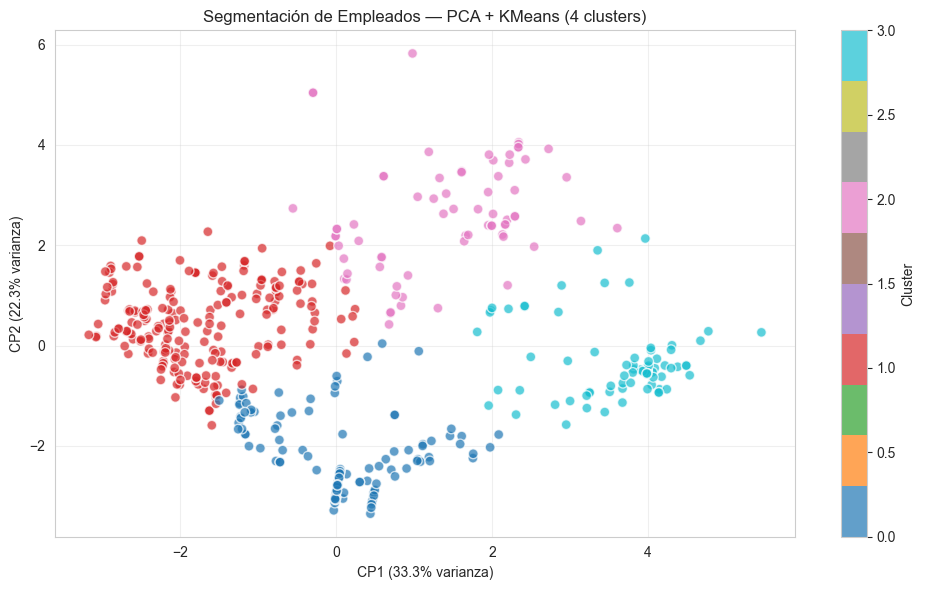

Varianza explicada acumulada: 55.5%

Empleados por cluster:
0    116
1    216
2     71
3     75


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

variables_cluster = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
    'ausencia_alta', 'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'competencias_tecnicas', 'competencias_blandas',
    'competencia_combinada', 'eficiencia_capacitacion', 'riesgo_operacional_rrhh'
]
variables_cluster = [v for v in variables_cluster if v in df.columns]

X = df[variables_cluster].copy()
pipe_pre = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler())])
X_prep = pipe_pre.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_prep)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters, cmap='tab10', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Empleados — PCA + KMeans (4 clusters)')
plt.xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"\nEmpleados por cluster:")
print(pd.Series(clusters).value_counts().sort_index().rename('n_empleados').to_string())


# 🔵 Perfiles de empleados — 4 clusters

| Cluster | Perfil | Señal principal |
|---|---|---|
| 0 | Alto desempeño | Competencias altas, pocas ausencias |
| 1 | Alta formación | Muchas horas de capacitación |
| 2 | Riesgo operacional | Ausencias frecuentes, bajas competencias |
| 3 | Estándar | Perfil promedio de la organización |

El clustering separó perfiles diferenciados **sin usar la variable objetivo**, validando la coherencia del dataset.


# 🟢 9. Conclusiones finales

---

# 🎯 Resumen de resultados reales

## Clasificación — `desempeno_alto`

| Modelo | F1 | Recall | Nota |
|---|---|---|---|
| **Decision Tree** (NB03) | **0.423** | 0.688 | Mejor global |
| RF Optuna (NB04) | 0.316 | 0.188 | Precision = 1.0 |
| Gaussian NB | 0.394 | 0.875 | Alto recall |

## Regresión — `puntaje_desempeno`

| Modelo | RMSE | R² test | R² CV |
|---|---|---|---|
| **SVR** (NB03) | **2.43** | 0.29 | 0.10 |
| RF Optuna (NB04) | 10.64 | -12.65 | — |

---

# 🎯 Hallazgos más relevantes

## 📈 El feature engineering fue fundamental

- `competencia_combinada`, `eficiencia_capacitacion`, `ausencia_alta`, `riesgo_operacional_rrhh`

---

## ⚠️ Limitación estructural del dataset

| Factor | Impacto |
|---|---|
| 309 empleados | Dataset pequeño para modelos de árbol |
| Features agregados por empleado | Pierde información temporal |
| R² bajo en regresión | ~10% de varianza explicada (SVR, CV) |

Este hallazgo es **válido académicamente**: refleja la dificultad real de predecir desempeño a partir de datos administrativos agregados.

---

## 🧠 El clustering confirmó patrones sin supervisión

KMeans + PCA identificó 4 grupos diferenciados sin usar el target, confirmando la coherencia del dataset.

---

# 🚀 Conclusión general

El proyecto demostró que Machine Learning puede detectar perfiles de empleados y clasificar alto desempeño transformando datos de RRHH en información estratégica para la gestión de personas.

La combinación de aprendizaje supervisado (clasificación + regresión), optimización de hiperparámetros y clustering no supervisado entrega una visión completa y metodológicamente sólida del problema.
